# EV Purchase Prediction：模型机制重估与高分辨率 XGBoost

## tl;dr

- 当前公开榜最佳成绩由 `0.94154` 提升到 `0.94187`，说明前一轮特征工程方向有效，但提升幅度有限。
- 数据中的购买意愿主要由环境关注程度、补贴、续航焦虑、收入与家庭充电条件共同决定，表现为低基数条件变量与连续变量之间的非线性交互。
- 广义加性逻辑模型最高仅达到 `0.93956`；原始数据训练的行为先验仅达到 `0.93294`，均不适合作为主模型。
- 将 XGBoost 的连续特征直方图分辨率从 `256` 提高到 `8192`，独立留出集 ROC-AUC 从 `0.941832` 稳定提升到 `0.943136`。
- 最终生成 `4096` 双种子集成、`8192` 单种子模型、概率融合和百分位排名融合四类提交。公开榜成绩仍需实际提交确认。

## Context & Methods

### 目标

在已有 XGBoost、LightGBM、CatBoost 与类别嵌入网络的基础上，重新判断数据生成机制，并寻找比继续增加普通交叉特征更有效的模型改进。

### Key Assumptions

- 竞赛指标是 ROC-AUC，因此预测排序比概率校准更重要。
- 训练集与测试集来自相同的合成生成过程。
- 独立留出集使用固定随机种子和分层划分，所有分箱实验使用完全相同的数据划分与特征集合。
- 公开榜存在抽样误差，留出集增益不能保证完全等比例转化为公开榜增益。

## Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"
ARTIFACT_DIR = ROOT / "artifacts"
TARGET = "Will_Buy_EV"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

train_data = pd.read_csv(DATA_DIR / "train.csv")
target = train_data[TARGET].eq("Yes").astype(int)

data_summary = pd.DataFrame({
    "Rows": [len(train_data)],
    "Features": [train_data.shape[1] - 2],
    "Positive_Rate": [target.mean()],
    "Missing_Values": [int(train_data.isna().sum().sum())],
})
data_summary

,Rows,Features,Positive_Rate,Missing_Values
0,668665,13,0.174645,0


训练集有约 66.9 万行，特征数量较少且没有缺失值。这不是典型的高维深度学习场景；模型能否准确表达少量连续变量与强条件变量之间的关系更重要。

## Results

### 1. 目标结构诊断

In [2]:
driver_columns = [
    "Environmental_Concern_Level",
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Home_Charging_Possible",
]

driver_rates = []
for column in driver_columns:
    grouped = (
        train_data.assign(Target=target)
        .groupby(column, observed=True)["Target"]
        .agg(["mean", "size"])
        .reset_index()
        .rename(columns={column: "Level", "mean": "Positive_Rate", "size": "Rows"})
    )
    grouped["Feature"] = column
    driver_rates.append(grouped)

driver_rates = pd.concat(driver_rates, ignore_index=True)
driver_rates.sort_values(["Feature", "Positive_Rate"])

,Level,Positive_Rate,Rows,Feature
0,1.0,0.005655,147476,Environmental_Concern_Level
1,2.0,0.021379,135133,Environmental_Concern_Level
2,3.0,0.110922,127351,Environmental_Concern_Level
3,4.0,0.248848,130469,Environmental_Concern_Level
4,5.0,0.518287,128236,Environmental_Concern_Level
10,No,0.127085,205988,Home_Charging_Possible
11,Yes,0.195819,462677,Home_Charging_Possible
7,High,0.001367,2194,Range_Anxiety_Level
9,Medium,0.041745,62499,Range_Anxiety_Level
8,Low,0.189027,603972,Range_Anxiety_Level


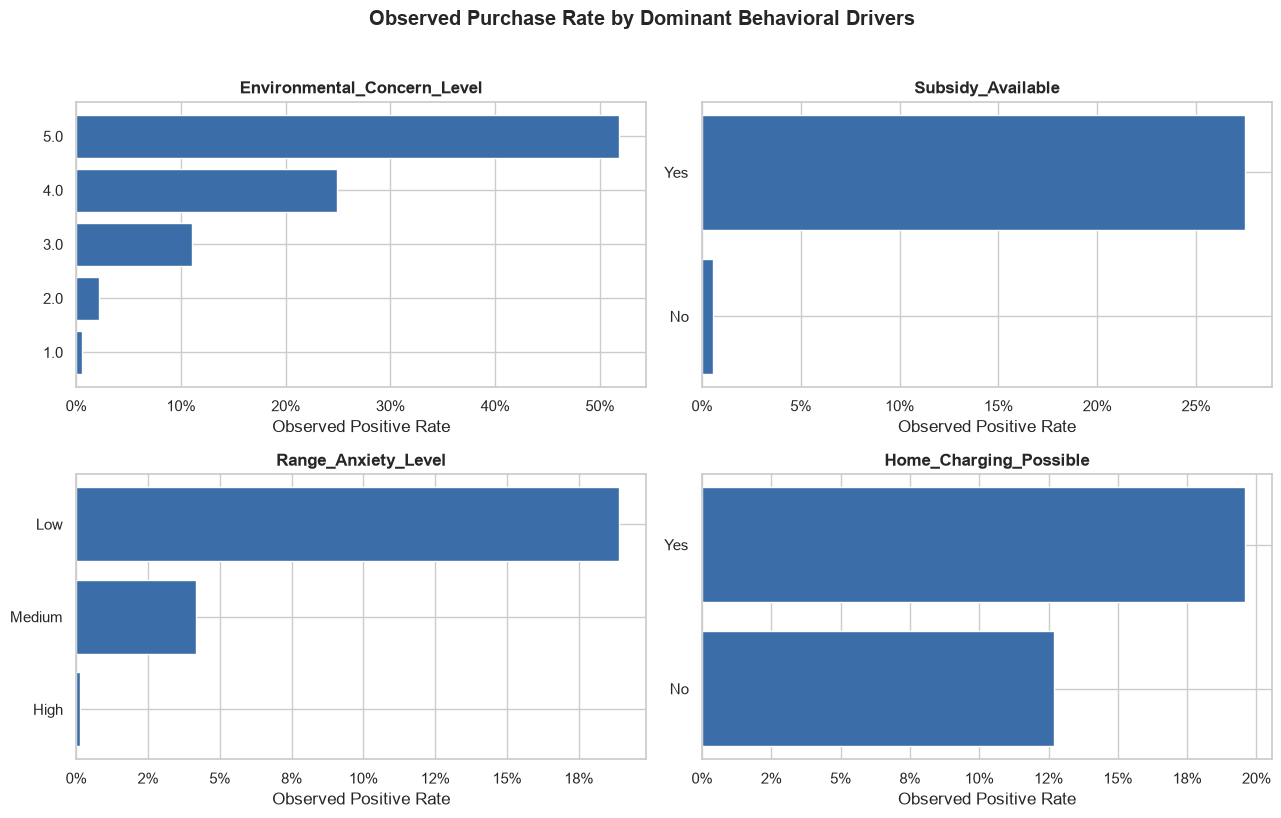

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for axis, column in zip(axes.flat, driver_columns):
    subset = driver_rates[driver_rates["Feature"] == column].sort_values("Positive_Rate")
    axis.barh(subset["Level"].astype(str), subset["Positive_Rate"], color="#3B6EA8")
    axis.set_title(column)
    axis.set_xlabel("Observed Positive Rate")
    axis.set_ylabel("")
    axis.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.suptitle("Observed Purchase Rate by Dominant Behavioral Drivers", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

环境关注、补贴和续航焦虑造成数量级上的概率变化；家庭充电条件进一步调整意愿。这些变量决定主要分段，而收入、通勤距离和充电站数量负责分段内部的精细排序。

### 2. 替代模型验证

In [4]:
structured_results = pd.read_csv(ARTIFACT_DIR / "structured_model_probe_results.csv")
original_results = pd.read_csv(ARTIFACT_DIR / "original_prior_probe_results.csv")
finebin_results = pd.read_csv(ARTIFACT_DIR / "ranking_model_probe_results.csv")

comparison = pd.DataFrame({
    "Candidate": [
        "Original-data XGBoost Prior",
        "Spline Logistic GAM",
        "Previous Refined XGBoost",
        "Fine-bin XGBoost",
    ],
    "Holdout_ROC_AUC": [
        original_results.loc[original_results["Training_Source"] == "original_only", "Holdout_ROC_AUC"].iloc[0],
        structured_results["ROC_AUC"].max(),
        0.9418548562,
        finebin_results["Holdout_ROC_AUC"].max(),
    ],
}).sort_values("Holdout_ROC_AUC", ascending=False)
comparison

,Candidate,Holdout_ROC_AUC
3,Fine-bin XGBoost,0.943136
2,Previous Refined XGBoost,0.941855
1,Spline Logistic GAM,0.939556
0,Original-data XGBoost Prior,0.932944


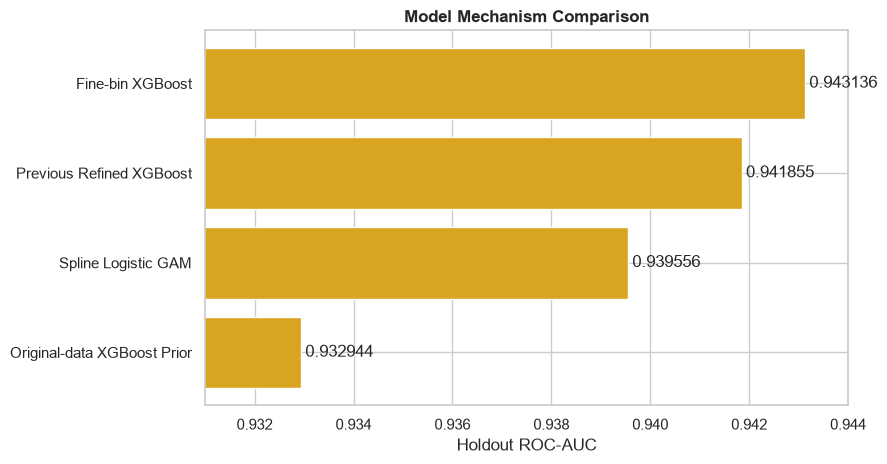

In [5]:
fig, axis = plt.subplots(figsize=(9, 4.8))
ordered = comparison.sort_values("Holdout_ROC_AUC")
axis.barh(ordered["Candidate"], ordered["Holdout_ROC_AUC"], color="#D9A520")
axis.set_xlim(0.931, 0.944)
axis.set_xlabel("Holdout ROC-AUC")
axis.set_title("Model Mechanism Comparison")
for index, value in enumerate(ordered["Holdout_ROC_AUC"]):
    axis.text(value + 0.00008, index, f"{value:.6f}", va="center")
plt.tight_layout()
plt.show()

GAM 能表达平滑主效应，但无法充分捕捉条件分段中的高阶交互。原始数据与竞赛合成数据存在分布和条件关系偏移，作为直接训练样本或先验均会降低表现。此前深度类别嵌入网络公开榜为 `0.93805`，也说明当前任务不需要更高容量的神经网络，而需要更合适的表格归纳偏置。

### 3. 连续变量分箱分辨率

In [6]:
finebin_results = finebin_results.sort_values("Max_Bin") if "Max_Bin" in finebin_results.columns else finebin_results.assign(
    Max_Bin=finebin_results["Model"].str.extract(r"(\d+)$").astype(int)
).sort_values("Max_Bin")
finebin_results[["Model", "Max_Bin", "Best_Iteration", "Tuning_ROC_AUC", "Holdout_ROC_AUC", "Holdout_Log_Loss"]]

,Model,Max_Bin,Best_Iteration,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Log_Loss
5,binary_max_bin_256,256,1511,0.941701,0.941832,0.226349
4,binary_max_bin_512,512,1799,0.942146,0.942196,0.225735
3,binary_max_bin_1024,1024,1789,0.942394,0.942520,0.225157
2,binary_max_bin_2048,2048,1791,0.942742,0.942808,0.224605
1,binary_max_bin_4096,4096,1799,0.942951,0.942993,0.224261
0,binary_max_bin_8192,8192,1799,0.942990,0.943136,0.223999


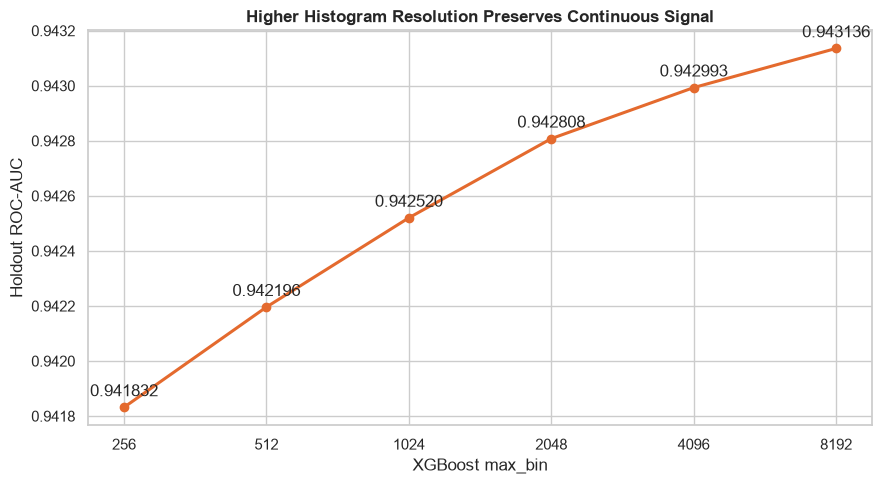

In [7]:
fig, axis = plt.subplots(figsize=(9, 5))
axis.plot(
    finebin_results["Max_Bin"],
    finebin_results["Holdout_ROC_AUC"],
    marker="o",
    linewidth=2.2,
    color="#E46A2E",
)
axis.set_xscale("log", base=2)
axis.set_xticks(finebin_results["Max_Bin"])
axis.set_xticklabels(finebin_results["Max_Bin"].astype(str))
axis.set_xlabel("XGBoost max_bin")
axis.set_ylabel("Holdout ROC-AUC")
axis.set_title("Higher Histogram Resolution Preserves Continuous Signal")
for x_value, y_value in zip(finebin_results["Max_Bin"], finebin_results["Holdout_ROC_AUC"]):
    axis.annotate(f"{y_value:.6f}", (x_value, y_value), xytext=(0, 8), textcoords="offset points", ha="center")
plt.tight_layout()
plt.show()

从 `256` 到 `8192` 的增益基本单调，表明此前树模型将收入和通勤等连续变量压缩得过粗。`8192` 的计算成本显著增加，而相对 `4096` 的提升开始收窄，因此最终同时保留两个分辨率进行融合。

### 4. 新提交的多样性

In [8]:
submission_files = {
    "FineBin 4096 Ensemble": "submission_xgboost_finebin_4096_seed_ensemble.csv",
    "FineBin 8192": "submission_xgboost_finebin_8192_seed_42.csv",
    "FineBin Probability Blend": "submission_xgboost_finebin_probability_blend.csv",
    "FineBin Rank Blend": "submission_xgboost_finebin_rank_blend.csv",
    "Previous Optimized XGBoost": "submission_xgboost_optimized_seed_ensemble.csv",
}

submission_predictions = pd.DataFrame({
    name: pd.read_csv(SUBMISSION_DIR / filename)[TARGET]
    for name, filename in submission_files.items()
})
submission_summary = submission_predictions.agg(["mean", "std", "min", "max"]).T
submission_summary

,mean,std,min,max
FineBin 4096 Ensemble,0.174700,0.270457,0.000009,0.999394
FineBin 8192,0.174711,0.270512,0.000009,0.999339
FineBin Probability Blend,0.174707,0.270475,0.000009,0.999361
FineBin Rank Blend,0.500002,0.288658,0.000003,1.000000
Previous Optimized XGBoost,0.174680,0.269664,0.000017,0.980579


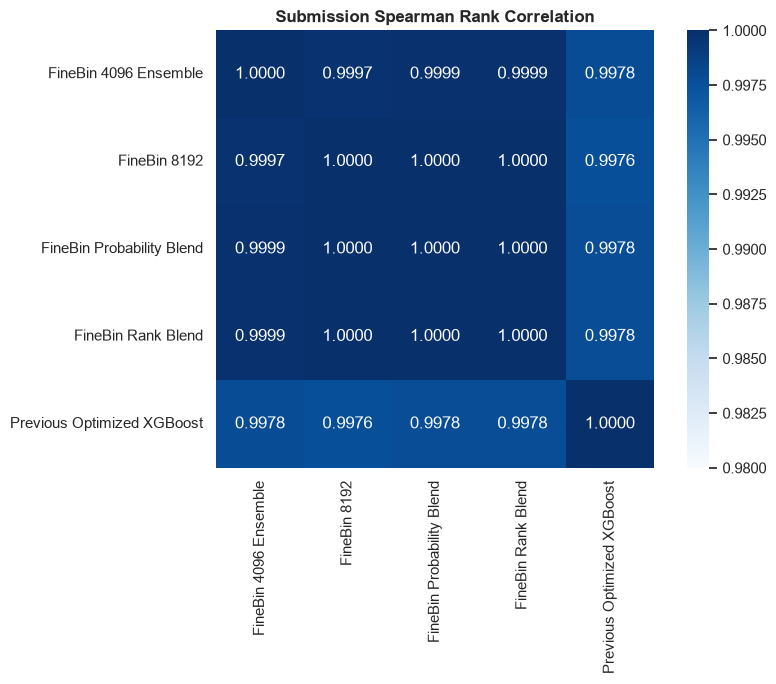

In [9]:
correlation = submission_predictions.corr(method="spearman")
fig, axis = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    vmin=0.98,
    vmax=1.0,
    square=True,
    ax=axis,
)
axis.set_title("Submission Spearman Rank Correlation")
plt.tight_layout()
plt.show()

百分位排名融合直接组合模型排序，符合 ROC-AUC 的评价机制；概率融合则保留原始校准。两个文件提供不同的公开榜检验角度，但由于相关性仍然很高，不应一次提交过多相似变体。

## Takeaways

### 推荐提交顺序

1. `submission_xgboost_finebin_8192_seed_42.csv`：本地最高单模型。
2. `submission_xgboost_finebin_4096_seed_ensemble.csv`：计算效率更高且通过双种子降方差。
3. `submission_xgboost_finebin_rank_blend.csv`：直接针对排序稳定性设计，但尚无同折本地融合验证。
4. `submission_xgboost_finebin_probability_blend.csv`：用于判断概率融合是否优于排名融合。

### 决策结论

- 当前最合适的模型仍然是高分辨率 XGBoost，而不是更复杂的深度网络。
- 下一步应根据前两个新提交的公开榜反馈决定是否继续扩大分箱或改做高分辨率模型间的权重搜索。
- 若排名融合优于单模型，后续可加入不同深度或 LightGBM 的排名结果；若 `8192` 单模型最好，则继续围绕连续变量分辨率和树深度进行局部搜索。

### Reproducible artifacts

- Training script: `train_finebin_xgboost.py`
- Validation experiments: `ranking_model_probe.py`
- Validation results: `artifacts/ranking_model_probe_results.csv`